In [12]:
import os
import random
import cv2
import numpy as np

input_dir = 'Agricultural_Image_Analytics/leaves'
output_dir = 'Augmented'

os.makedirs(output_dir, exist_ok=True)

source_images = [f"I{i}.png" for i in range(1, 9)]
source_image_paths = [os.path.join(input_dir, f) for f in source_images]

for i in range(100):
    source_path = random.choice(source_image_paths)
    source_filename = os.path.basename(source_path)
    
    img = cv2.imread(source_path)
    h, w = img.shape[:2]
    batch_idx = i // 25  
    
    if batch_idx == 0:
        # ROTATE (0 to 360 degrees) 
        angle = random.uniform(0, 360)
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, scale=1.0)
        aug_img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "rotate"
        
    elif batch_idx == 1:
        # SHIFT (Up to 50% of width/height)
        tx = random.uniform(-w * 0.5, w * 0.5)
        ty = random.uniform(-h * 0.5, h * 0.5)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        aug_img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "shift"
        
    elif batch_idx == 2:
        # SCALE (0.5x to 2.0x)
        scale = random.uniform(0.5, 2.0)
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle=0, scale=scale)
        aug_img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "scale"
        
    else:
        # WARP (Up to 25% distortion on corners)
        src_points = np.float32([[0, 0], [w-1, 0], [0, h-1], [w-1, h-1]])
        dx = w * 0.25
        dy = h * 0.25
        dst_points = np.float32([
            [random.uniform(0, dx), random.uniform(0, dy)], 
            [w-1 - random.uniform(0, dx), random.uniform(0, dy)], 
            [random.uniform(0, dx), h-1 - random.uniform(0, dy)], 
            [w-1 - random.uniform(0, dx), h-1 - random.uniform(0, dy)]
        ])
        M = cv2.getPerspectiveTransform(src_points, dst_points)
        aug_img = cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        prefix = "warp"

    new_filename = f"{prefix}_{i+1:03d}_from_{source_filename}"
    output_path = os.path.join(output_dir, new_filename)
    cv2.imwrite(output_path, aug_img)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.image import extract_patches_2d

# --- Task 2: Extract Local Patches ---
all_patches = []
# Ensure output_dir is defined from your previous steps
for filename in [f for f in os.listdir(output_dir) if f.endswith('.png')]:
    img = cv2.imread(os.path.join(output_dir, filename))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    patches = extract_patches_2d(img, patch_size=(32, 32), max_patches=10)
    all_patches.append(patches)

X = np.array(all_patches).reshape(-1, 32 * 32 * 3) 
X_original = X.copy()

# --- Task 3: ZCA Whitening ---
def zca_whitening(X):
    # 1. Zero-centering (UFLDL Step 0b)
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    
    # 2. Covariance
    sigma = np.dot(X_centered.T, X_centered) / X_centered.shape[0]
    
    # 3. SVD
    U, S, V = np.linalg.svd(sigma)
    
    # 4. ZCA Transform Math (UFLDL Step 4 & 5)
    epsilon = 0.1 
    # PCA Whitening
    xPCAwhite = np.dot(X_centered, np.dot(U, np.diag(1.0 / np.sqrt(S + epsilon))))
    # ZCA Whitening (Rotating back to pixel space)
    X_ZCA = np.dot(xPCAwhite, U.T)
    
    return X_ZCA

X_white = zca_whitening(X)


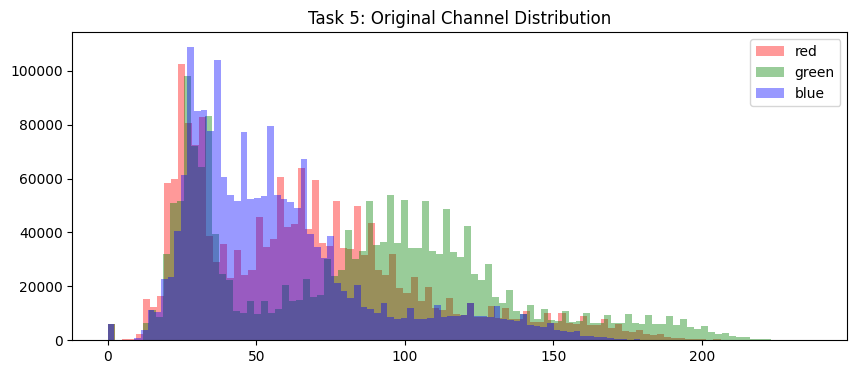

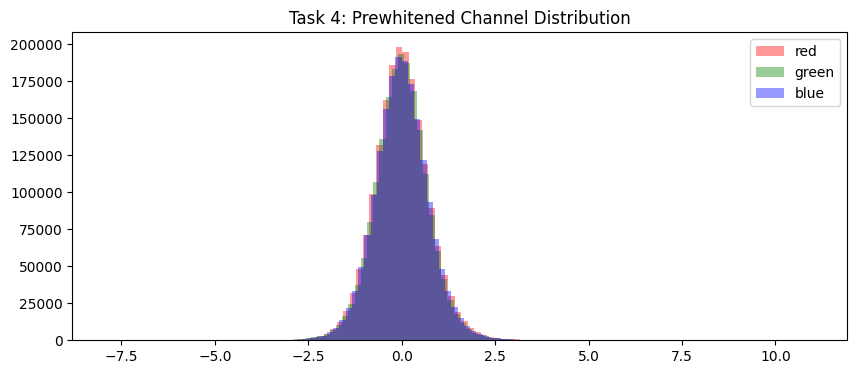

In [17]:

# --- Task 4 & 5: Display Distributions ---
def plot_dist(data, title):
    # Reshape back to images to get R, G, B channels
    data_img = data.reshape(-1, 32, 32, 3)
    plt.figure(figsize=(10, 4))
    for i, col in enumerate(['red', 'green', 'blue']):
        plt.hist(data_img[:,:,:,i].flatten(), bins=100, color=col, alpha=0.4, label=col)
    plt.title(title)
    plt.legend()
    plt.show()

plot_dist(X_original, "Task 5: Original Channel Distribution")
plot_dist(X_white, "Task 4: Prewhitened Channel Distribution")

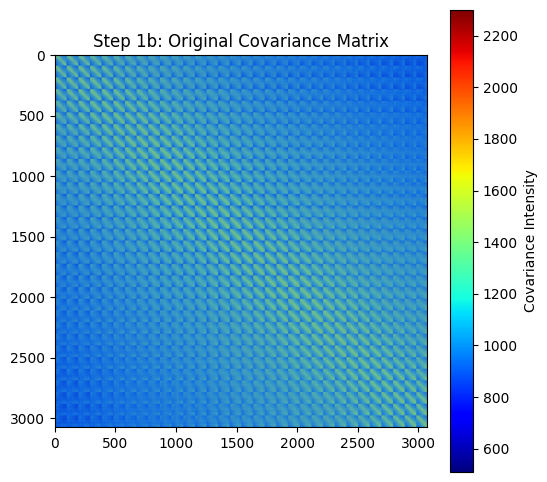

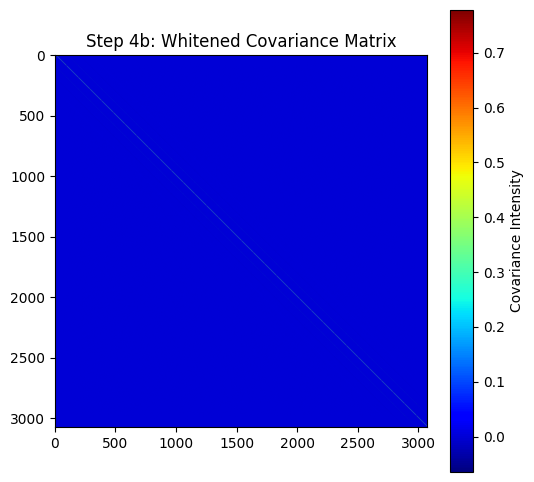

In [21]:
def visualize_covariance(data, title):
    # Calculate covariance matrix
    cov = np.cov(data, rowvar=False)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cov, cmap='jet')
    plt.title(title)
    plt.colorbar(label='Covariance Intensity')
    plt.show()

visualize_covariance(X_original, "Step 1b: Original Covariance Matrix")
visualize_covariance(X_white, "Step 4b: Whitened Covariance Matrix")

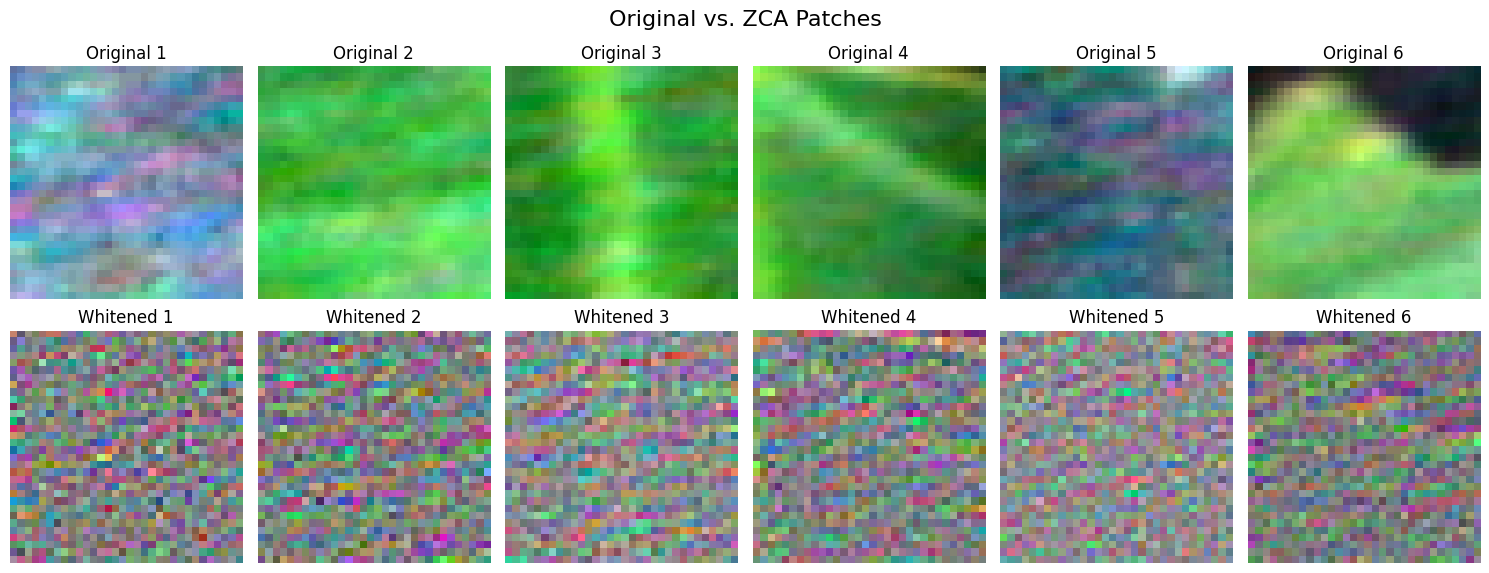

In [22]:
import matplotlib.pyplot as plt

def plot_6_comparison(original_data, whitened_data):
    orig_imgs = original_data.reshape(-1, 32, 32, 3)
    white_imgs = whitened_data.reshape(-1, 32, 32, 3)
    
    
    fig, axes = plt.subplots(2, 6, figsize=(15, 6))
    
    for i in range(6):
        img_o = orig_imgs[i]
        # Normalize
        img_o_norm = (img_o - img_o.min()) / (img_o.max() - img_o.min())
        
        axes[0, i].imshow(img_o_norm)
        axes[0, i].set_title(f"Original {i+1}")
        axes[0, i].axis('off')
        
        img_w = white_imgs[i]
        # Normalize
        img_w_norm = (img_w - img_w.min()) / (img_w.max() - img_w.min())
        
        axes[1, i].imshow(img_w_norm)
        axes[1, i].set_title(f"Whitened {i+1}")
        axes[1, i].axis('off')

    plt.suptitle("Original vs. ZCA Patches", fontsize=16)
    plt.tight_layout()
    plt.show()

# Execute the visualization
plot_6_comparison(X_original, X_white)

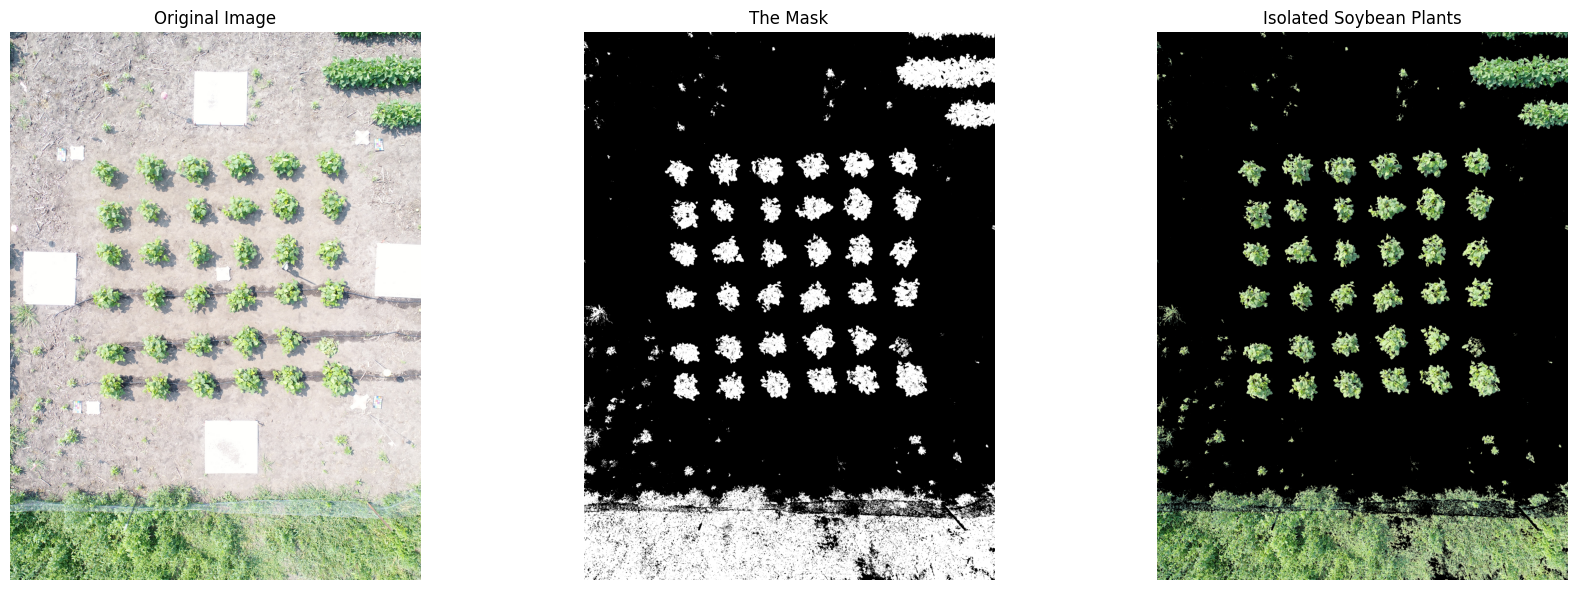

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'Agricultural_Image_Analytics/2.JPG' 
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv, lower_green, upper_green)
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("The Mask")
axes[1].axis('off')

axes[2].imshow(result)
axes[2].set_title("Isolated Soybean Plants")
axes[2].axis('off')

plt.tight_layout()
plt.show()

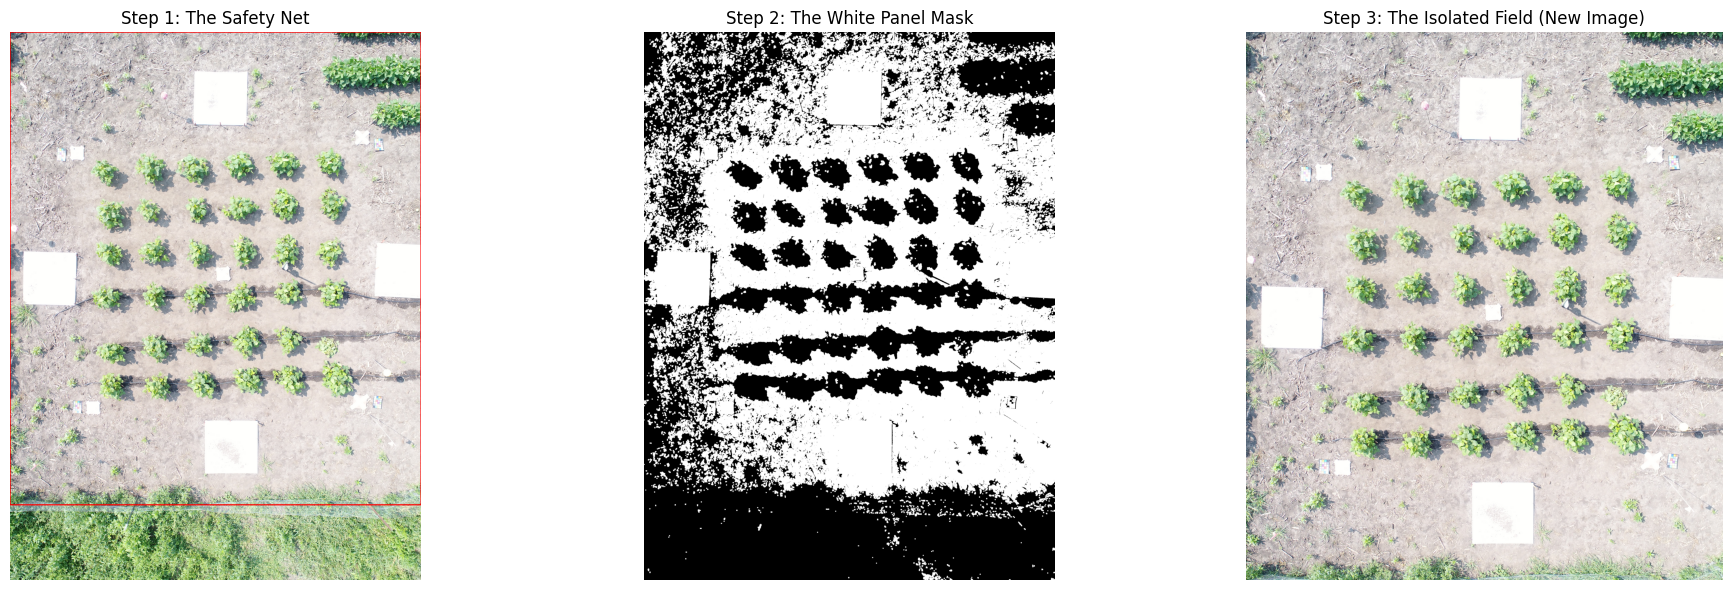

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'Agricultural_Image_Analytics/2.JPG' 
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Could not load {image_path}")
    
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_white = np.array([0, 0, 180])
upper_white = np.array([180, 50, 255])

white_mask = cv2.inRange(hsv, lower_white, upper_white)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel)

contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)[:4]

# Stack all the points from all 4 panels into one giant array
all_points = np.vstack(contours)
x, y, w, h = cv2.boundingRect(all_points)
net_img = img_rgb.copy()
cv2.rectangle(net_img, (x, y), (x + w, y + h), (255, 0, 0), 10) 

safe_roi = img_rgb[y:y+h, x:x+w]

# plotting 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(net_img)
axes[0].set_title("Step 1: The Safety Net")
axes[0].axis('off')

axes[1].imshow(white_mask, cmap='gray')
axes[1].set_title("Step 2: The White Panel Mask")
axes[1].axis('off')

axes[2].imshow(safe_roi)
axes[2].set_title("Step 3: The Isolated Field (New Image)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

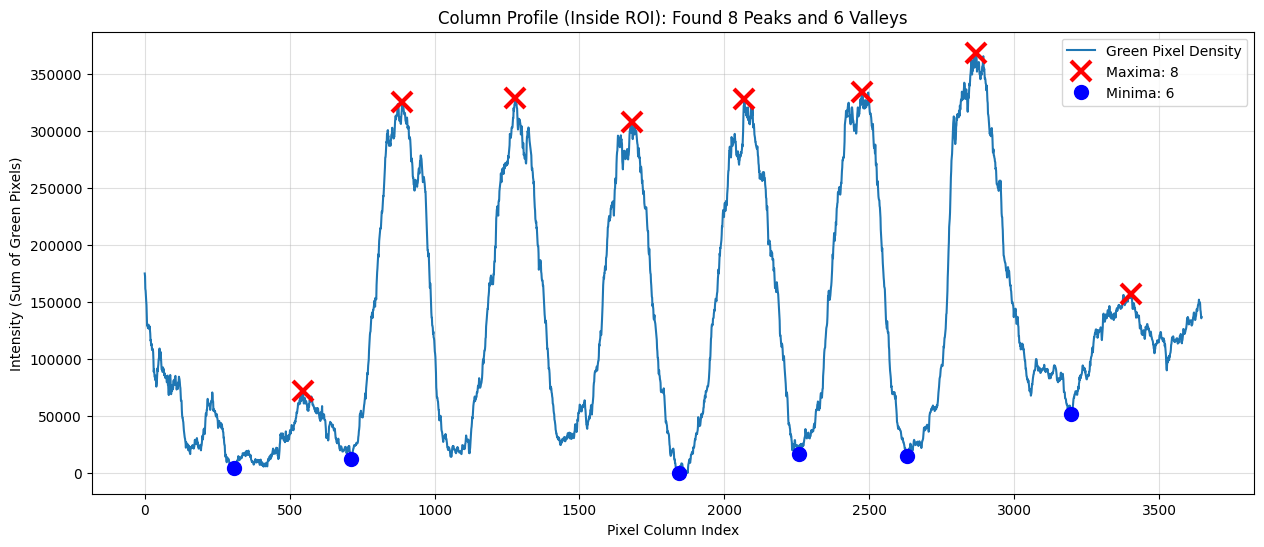

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

image_path = 'Agricultural_Image_Analytics/2.JPG' 
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Isolate white panels
lower_white = np.array([0, 0, 180])
upper_white = np.array([180, 50, 255])
white_mask = cv2.inRange(hsv, lower_white, upper_white)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel)

# Find boundaries and crop
contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:4]

if len(contours) < 4:
    print(f"Warning: Only found {len(contours)} white panels instead of 4.")

all_points = np.vstack(contours)
x, y, w, h = cv2.boundingRect(all_points)
safe_roi = img_rgb[y:y+h, x:x+w]
roi_hsv = cv2.cvtColor(safe_roi, cv2.COLOR_RGB2HSV)

# green threshold values
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
green_mask = cv2.inRange(roi_hsv, lower_green, upper_green)
col_profile = np.sum(green_mask, axis=0)

# Find the Maxima
min_distance_cols = safe_roi.shape[1] // 190 

prominence_cols = np.max(col_profile) * 0.15 
col_peaks, _ = find_peaks(col_profile, distance=min_distance_cols, prominence=prominence_cols)

# Find the Minima
inverted_profile = col_profile.astype(np.int64) * -1
min_distance_valleys = safe_roi.shape[1] // 10

prominence_valleys = np.max(col_profile) * 0.05 
col_valleys, _ = find_peaks(inverted_profile, distance=min_distance_valleys, prominence=prominence_valleys)
plt.figure(figsize=(15, 6))
plt.plot(col_profile, label="Green Pixel Density")

plt.plot(col_peaks, col_profile[col_peaks], "x", color='red', markersize=15, markeredgewidth=3, label=f"Maxima: {len(col_peaks)}")
plt.plot(col_valleys, col_profile[col_valleys], "o", color='blue', markersize=10, label=f"Minima: {len(col_valleys)}")

plt.title(f"Column Profile (Inside ROI): Found {len(col_peaks)} Peaks and {len(col_valleys)} Valleys")
plt.xlabel("Pixel Column Index")
plt.ylabel("Intensity (Sum of Green Pixels)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

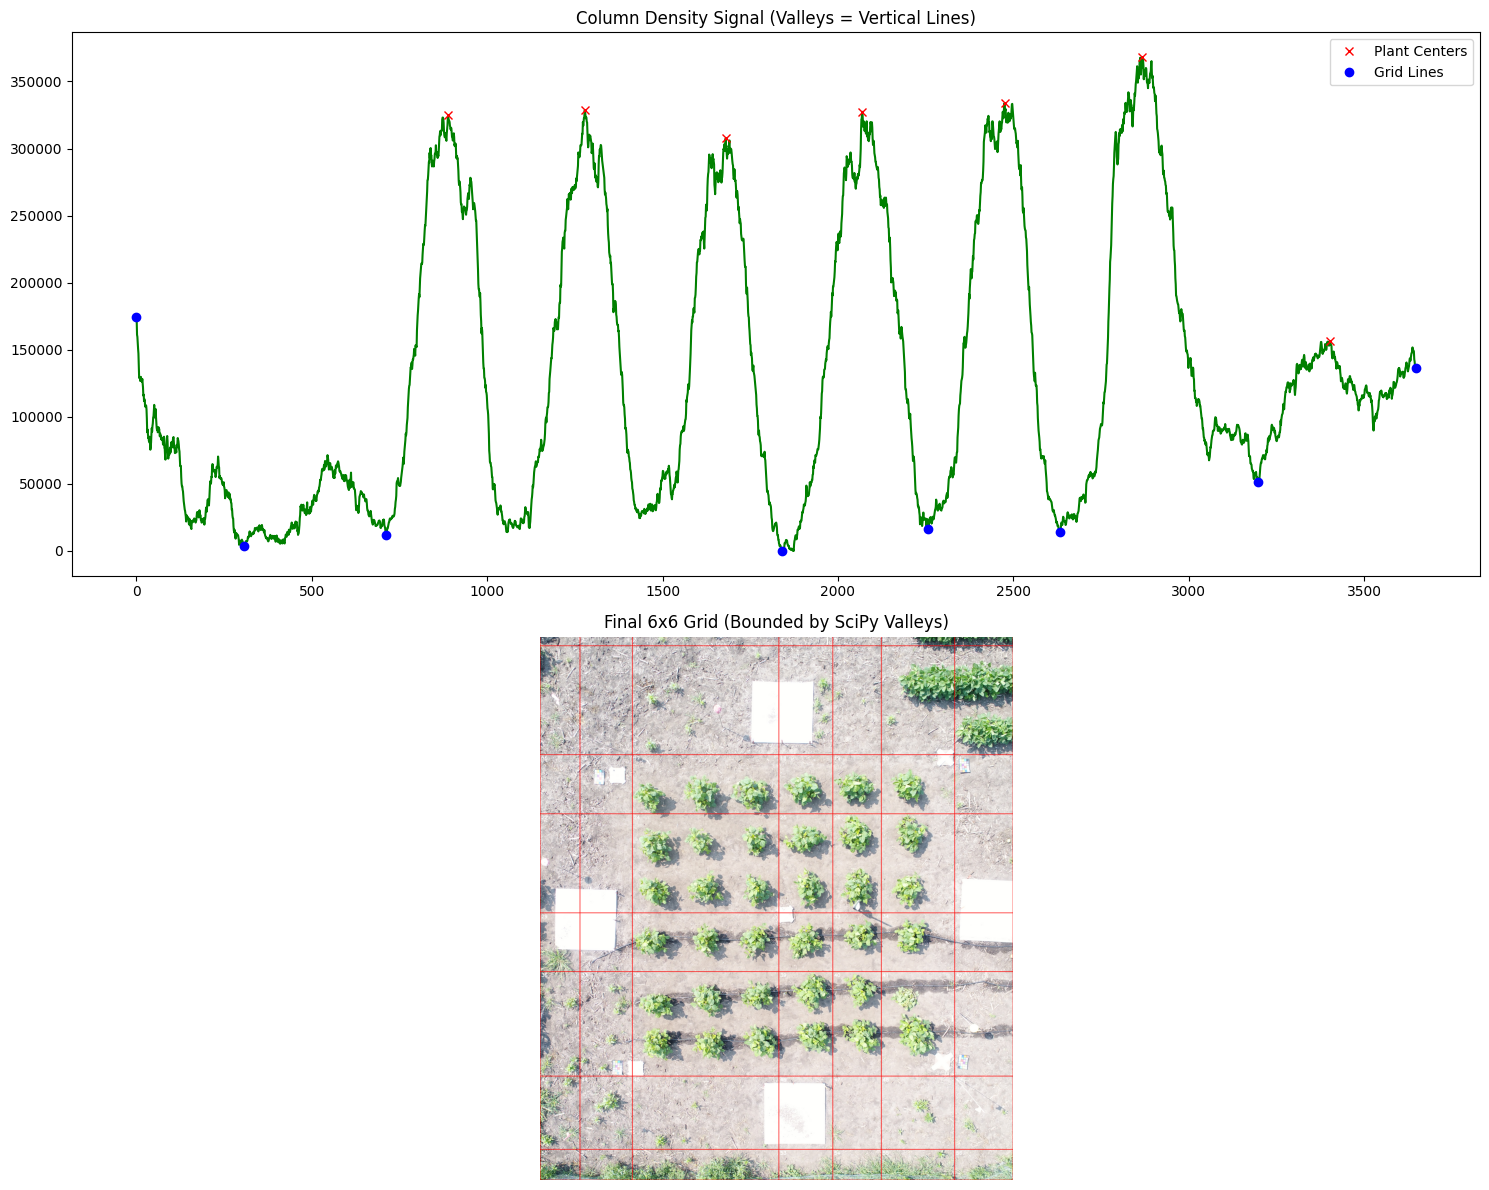

In [183]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

image_path = 'Agricultural_Image_Analytics/2.JPG' 
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_white = np.array([0, 0, 180])
upper_white = np.array([180, 50, 255])
white_mask = cv2.inRange(hsv, lower_white, upper_white)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel)

contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:4]
all_points = np.vstack(contours)
x_crop, y_crop, w_crop, h_crop = cv2.boundingRect(all_points)
safe_roi = img_rgb[y_crop:y_crop+h_crop, x_crop:x_crop+w_crop]
roi_hsv = cv2.cvtColor(safe_roi, cv2.COLOR_RGB2HSV)

lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
green_mask = cv2.inRange(roi_hsv, lower_green, upper_green)

# X-Axis (Columns)
col_profile = np.sum(green_mask, axis=0)
# Y-Axis (Rows) - Summing along axis 1 creates the vertical profile
row_profile = np.sum(green_mask, axis=1)

def get_separators(profile, size_dim):
    min_dist = size_dim // 10 
    prominence = np.max(profile) * 0.15
    peaks, _ = find_peaks(profile, distance=min_dist, prominence=prominence)
    inverted = profile.astype(np.int64) * -1
    v_prominence = np.max(profile) * 0.05
    valleys, _ = find_peaks(inverted, distance=min_dist, prominence=v_prominence)
    
    boundaries = np.sort(np.concatenate(([0], valleys, [size_dim])))
    return peaks, boundaries

col_peaks, col_bounds = get_separators(col_profile, safe_roi.shape[1])
row_peaks, row_bounds = get_separators(row_profile, safe_roi.shape[0])

output_grid = safe_roi.copy()
count = 1

for i in range(len(row_bounds) - 1):
    for j in range(len(col_bounds) - 1):
        # Coordinates defined by the valleys
        y1, y2 = row_bounds[i], row_bounds[i+1]
        x1, x2 = col_bounds[j], col_bounds[j+1]
        
        cv2.rectangle(output_grid, (x1, y1), (x2, y2), (255, 0, 0), 4)
        
        cv2.putText(output_grid, str(count), (x1 + 10, y1 + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)
        count += 1

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

axes[0].plot(col_profile, color='green')
axes[0].plot(col_peaks, col_profile[col_peaks], "x", color='red', label='Plant Centers')
axes[0].plot(col_bounds, col_profile[col_bounds.clip(0, len(col_profile)-1)], "o", color='blue', label='Grid Lines')
axes[0].set_title("Column Density Signal (Valleys = Vertical Lines)")
axes[0].legend()

axes[1].imshow(output_grid)
axes[1].set_title("Final 6x6 Grid (Bounded by SciPy Valleys)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

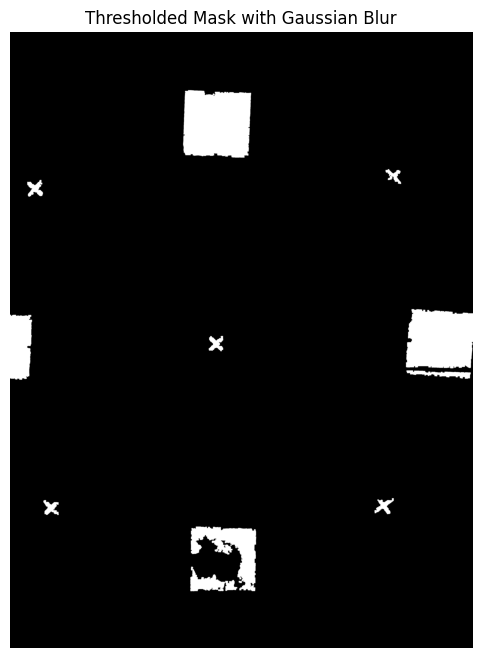

In [184]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'Agricultural_Image_Analytics/3.JPG'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blurred_img = cv2.GaussianBlur(img, (5, 5), 0)
hsv = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2HSV)

# 2. Thresholding
lower_white = np.array([0, 0, 245]) 
upper_white = np.array([180, 2, 255]) 
white_mask = cv2.inRange(hsv, lower_white, upper_white)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))
white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel)

contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
final_mask = np.zeros_like(white_mask)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 2500: 
        cv2.drawContours(final_mask, [cnt], -1, 255, -1)

plt.figure(figsize=(12, 8))
plt.imshow(final_mask, cmap='gray')
plt.title("Thresholded Mask with Gaussian Blur")
plt.axis('off')
plt.show()

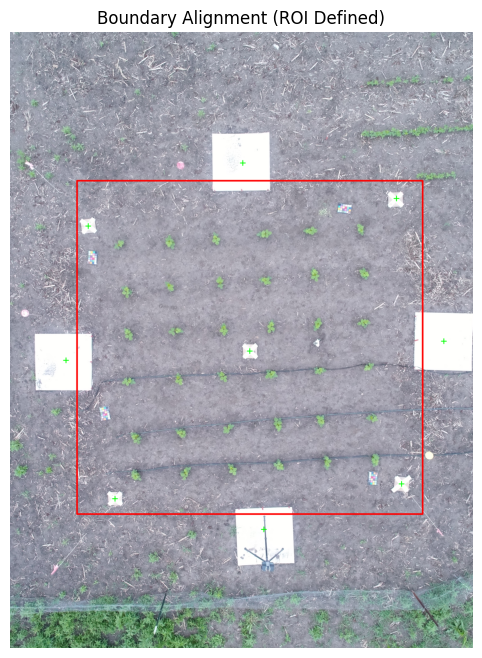

In [186]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'Agricultural_Image_Analytics/1.JPG'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
image_thawed = cv2.GaussianBlur(img, (11, 11), 0)
hsv_image = cv2.cvtColor(image_thawed, cv2.COLOR_BGR2HSV)
# Tweak this val to make sure I got it all good...
low_white = np.array([20, 0, 245]) 
high_white = np.array([180, 2, 255]) 
raw_mask = cv2.inRange(hsv_image, low_white, high_white)

cleaning_tool = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))
clean_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, cleaning_tool)

found_shapes, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

potential_markers = []
for shape in found_shapes:
    size = cv2.contourArea(shape)
    if size > 150: 
        x, y, w, h = cv2.boundingRect(shape)
        shape_ratio = float(w) / h
        if 0.2 <= shape_ratio <= 4.0:
            moments = cv2.moments(shape)
            if moments["m00"] != 0:
                center_x = int(moments["m10"] / moments["m00"])
                center_y = int(moments["m01"] / moments["m00"])
                potential_markers.append({'pos': (center_x, center_y), 'size': size})

# --- SORTING THE BEST GEMS ---
final_points = []
if potential_markers:
    potential_markers = sorted(potential_markers, key=lambda x: x['size'], reverse=True)
    for marker in potential_markers:
        pos = marker['pos']
        already_found = False
        for saved_pos in final_points:
            gap = np.sqrt((pos[0] - saved_pos[0])**2 + (pos[1] - saved_pos[1])**2)
            if gap < 40:
                already_found = True
                break
        if not already_found:
            final_points.append(pos)

final_points = final_points[:9]

# --- SETTING THE BOUNDARIES & DEFINING ROI ---
if len(final_points) >= 4:
    x_coords = sorted([p[0] for p in final_points])
    y_coords = sorted([p[1] for p in final_points])
    
    # Anchor the box using the average of the two most extreme points
    left_edge   = int(np.mean(x_coords[:2]))
    right_edge  = int(np.mean(x_coords[-2:]))
    top_edge    = int(np.mean(y_coords[:2]))
    bottom_edge = int(np.mean(y_coords[-2:]))

    # --- THE DEFINITION OF FINAL ROI ---
    # Slicing the image: [y_start:y_end, x_start:x_end]
    # We add/subtract 10 pixels to avoid clipping edge plants
    final_roi = img_rgb[max(0, top_edge-10) : min(img_rgb.shape[0], bottom_edge+10), 
                        max(0, left_edge-10) : min(img_rgb.shape[1], right_edge+10)]

    # --- THE FINAL REVEAL ---
    final_view = img_rgb.copy()
    cv2.rectangle(final_view, (left_edge, top_edge), (right_edge, bottom_edge), (255, 0, 0), 12)
    
    for point in final_points:
        cv2.drawMarker(final_view, point, (0, 255, 0), cv2.MARKER_CROSS, 40, 5)

    plt.figure(figsize=(12, 8))
    plt.imshow(final_view)
    plt.title(f"Boundary Alignment (ROI Defined)")
    plt.axis('off')
    plt.show()
    
else:
    print(f"Found {len(final_points)}")

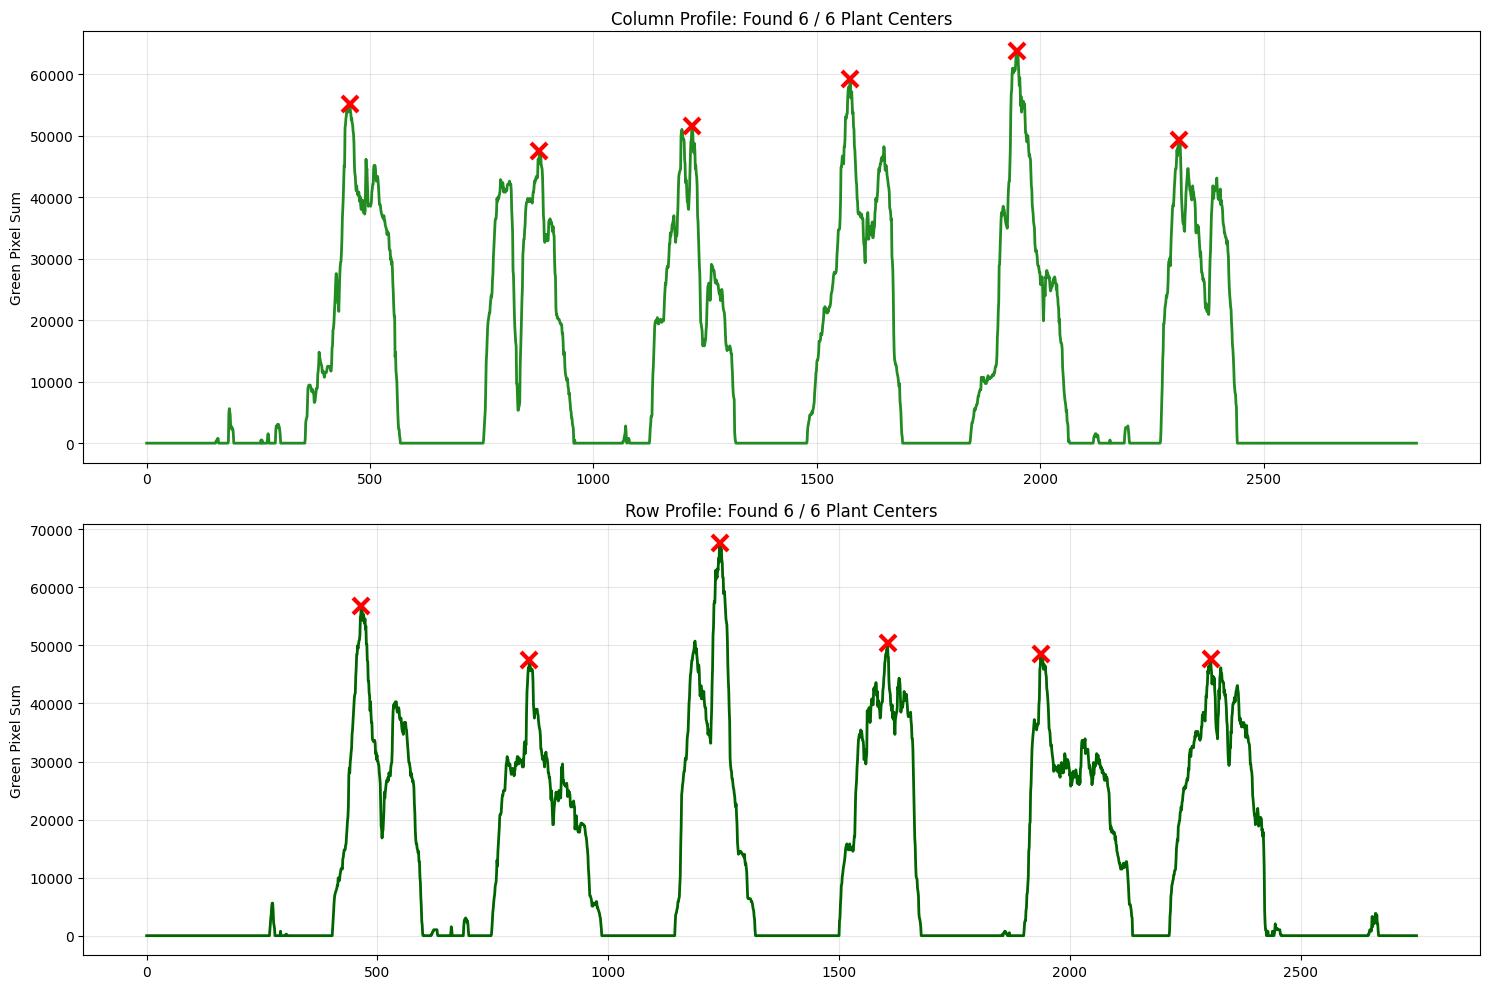

In [189]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

roi_hsv = cv2.cvtColor(final_roi, cv2.COLOR_RGB2HSV)
green_mask = cv2.inRange(roi_hsv, np.array([35, 40, 40]), np.array([85, 255, 255]))

def get_padded_profile(mask, axis):
    profile = np.sum(mask, axis=axis)
    return np.pad(profile, (50, 50), 'constant', constant_values=0)

col_profile_raw = get_padded_profile(green_mask, 0)
row_profile_raw = get_padded_profile(green_mask, 1)

def find_six_peaks(profile):
    p_dist = len(profile) // 10
    p_prom = np.max(profile) * 0.08 
    
    peaks, _ = find_peaks(profile, distance=p_dist, prominence=p_prom)
    
    if len(peaks) > 6:
        peak_intensities = profile[peaks]
        top_indices = np.argsort(peak_intensities)[-6:]
        peaks = sorted(peaks[top_indices])
        
    return peaks

col_peaks = find_six_peaks(col_profile_raw)
row_peaks = find_six_peaks(row_profile_raw)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
ax1.plot(col_profile_raw, color='forestgreen', linewidth=2)
ax1.plot(col_peaks, col_profile_raw[col_peaks], "x", color='red', markersize=12, markeredgewidth=3)
ax1.set_title(f"Column Profile: Found {len(col_peaks)} / 6 Plant Centers")
ax1.set_ylabel("Green Pixel Sum")
ax1.grid(True, alpha=0.3)

ax2.plot(row_profile_raw, color='darkgreen', linewidth=2)
ax2.plot(row_peaks, row_profile_raw[row_peaks], "x", color='red', markersize=12, markeredgewidth=3)
ax2.set_title(f"Row Profile: Found {len(row_peaks)} / 6 Plant Centers")
ax2.set_ylabel("Green Pixel Sum")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

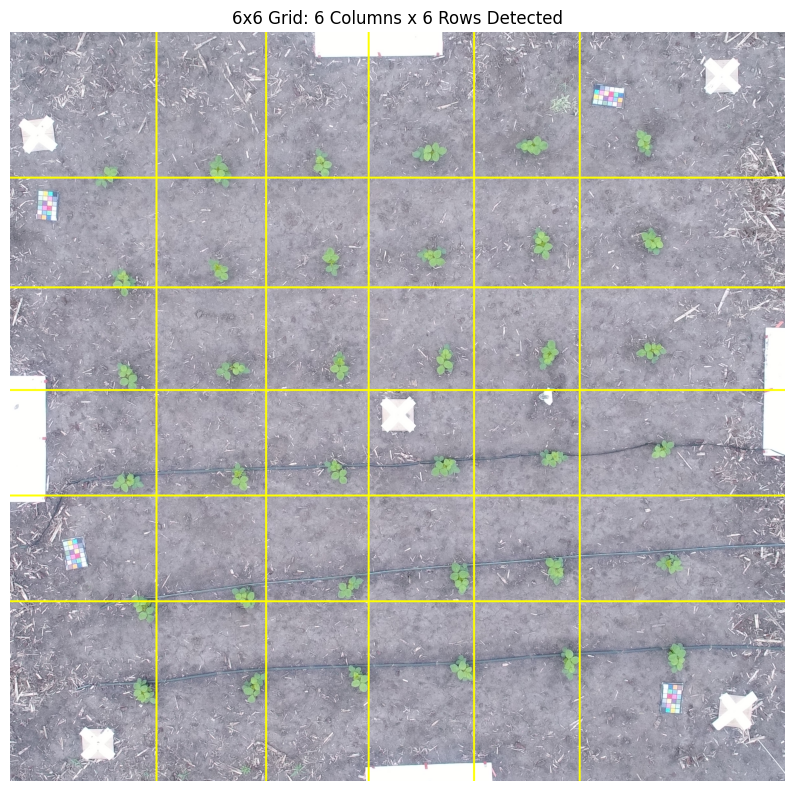

In [190]:
def find_dividing_lines(profile, peaks):
    # Invert the profile to find valleys
    inverted = (np.max(profile) - profile)
    # We find valleys specifically in the regions between our identified peaks
    valleys = []
    for i in range(len(peaks) - 1):
        search_area = profile[peaks[i]:peaks[i+1]]
        valley_idx = np.argmin(search_area) + peaks[i]
        valleys.append(valley_idx)
    
    actual_valleys = [v - 50 for v in valleys]
    return actual_valleys

col_dividers = find_dividing_lines(col_profile_raw, col_peaks)
row_dividers = find_dividing_lines(col_profile_raw, row_peaks)

# DRAW THE 6x6 GRID
grid_view = final_roi.copy()
h, w, _ = grid_view.shape
for vx in col_dividers:
    cv2.line(grid_view, (vx, 0), (vx, h), (255, 255, 0), 5)
for vy in row_dividers:
    cv2.line(grid_view, (0, vy), (w, vy), (255, 255, 0), 5)

# Final Plot
plt.figure(figsize=(10, 10))
plt.imshow(grid_view)
plt.title(f"6x6 Grid: {len(col_dividers)+1} Columns x {len(row_dividers)+1} Rows Detected")
plt.axis('off')
plt.show()

Done: 1.JPG
Done: 2.JPG
Done: 3.JPG
Done: 4.JPG
Done: 5.JPG


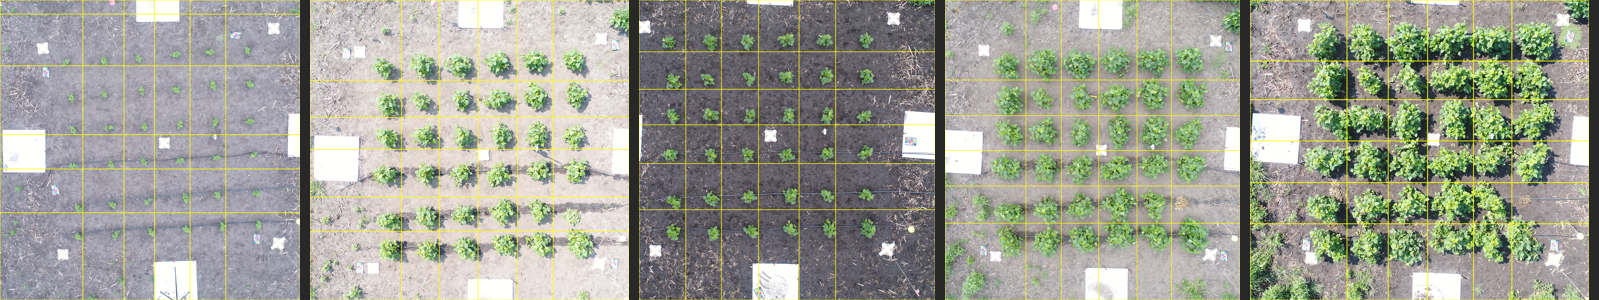

In [191]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import find_peaks

# --- CONFIGURATION ---
image_folder = 'Agricultural_Image_Analytics'
image_names = ['1.JPG', '2.JPG', '3.JPG', '4.JPG', '5.JPG']
thumbnails = []

def get_grid_dividers(profile, count):
    padded = np.pad(profile, (50, 50), 'constant', constant_values=0)
    p_dist = len(padded) // 10
    peaks, _ = find_peaks(padded, distance=p_dist, prominence=np.max(padded)*0.08)
    
    # Ensure we only work with the 6 best peaks
    if len(peaks) > count:
        top_idx = np.argsort(padded[peaks])[-count:]
        peaks = sorted(peaks[top_idx])
        
    valleys = []
    for i in range(len(peaks) - 1):
        v_idx = np.argmin(padded[peaks[i]:peaks[i+1]]) + peaks[i]
        valleys.append(v_idx - 50)
    return sorted(list(set([0] + valleys + [len(profile)])))

for name in image_names:
    img = cv2.imread(os.path.join(image_folder, name))
    if img is None: continue
    blur = cv2.GaussianBlur(img, (11, 11), 0)
    hsv = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([20, 0, 245]), np.array([180, 2, 255]))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pts = []
    for c in cnts:
        if cv2.contourArea(c) > 150:
            M = cv2.moments(c)
            if M["m00"] != 0:
                pts.append((int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])))
    
    final_pts = []
    for p in sorted(pts, key=lambda x: x[1]):
        if not any(np.linalg.norm(np.array(p)-np.array(f)) < 50 for f in final_pts):
            final_pts.append(p)
    
    if len(final_pts) >= 4:
        xs, ys = sorted([p[0] for p in final_pts]), sorted([p[1] for p in final_pts])
        lx, rx, ty, by = int(np.mean(xs[:2])), int(np.mean(xs[-2:])), int(np.mean(ys[:2])), int(np.mean(ys[-2:]))
        roi = cv2.cvtColor(img[ty:by, lx:rx], cv2.COLOR_BGR2RGB)
        g_mask = cv2.inRange(cv2.cvtColor(roi, cv2.COLOR_RGB2HSV), np.array([35, 40, 40]), np.array([85, 255, 255]))
        x_divs = get_grid_dividers(np.sum(g_mask, axis=0), 6)
        y_divs = get_grid_dividers(np.sum(g_mask, axis=1), 6)
        
        #Save 36 plots to folder
        folder_name = name.split('.')[0]
        os.makedirs(folder_name, exist_ok=True)
        for r in range(len(y_divs)-1):
            for c in range(len(x_divs)-1):
                cell = roi[y_divs[r]:y_divs[r+1], x_divs[c]:x_divs[c+1]]
                if cell.size > 0:
                    cv2.imwrite(f"{folder_name}/p_{r}_{c}.png", cv2.cvtColor(cell, cv2.COLOR_RGB2BGR))
        
        # Create Thumbnail for viewing
        grid_preview = roi.copy()
        for x in x_divs: cv2.line(grid_preview, (x, 0), (x, grid_preview.shape[0]), (255, 255, 0), 6)
        for y in y_divs: cv2.line(grid_preview, (0, y), (grid_preview.shape[1], y), (255, 255, 0), 6)
        pil_img = Image.fromarray(grid_preview)
        aspect = pil_img.width / pil_img.height
        thumbnails.append(pil_img.resize((int(300 * aspect), 300)))
        print(f"Done: {name}")

if thumbnails:
    total_width = sum(t.width for t in thumbnails) + (len(thumbnails) * 10)
    combined = Image.new('RGB', (total_width, 300), (40, 40, 40))
    
    current_x = 0
    for t in thumbnails:
        combined.paste(t, (current_x, 0))
        current_x += t.width + 10
    
    display(combined)